<div style="text-align: center; margin-bottom: 10px;">
  <img src="assets/logo.png" width="200">
</div>

<h1 style="text-align: center;">
Operational ML: Routing High-Risk Work to Protect SLAs
</h1>

<h3 style="text-align: center;">
Predict intake risk to proactively route work: priority queue, rebalance instruments, and adjust staffing.
</h3>

<hr style="border: 1px solid #cfd8dc; width: 60%;">

## Executive summary

- **Decision:** Score incoming work at intake and route the **top 10%** highest-risk work items to a priority queue.
- **Target:** Predict **P90 slow cycle time** within comparable work (instrument type × test type).
- **Validation:** **Instrument-held-out** cross-validation (GroupKFold) to test generalization beyond any single instrument.
- **Stakeholder view:** Map scores to a **service target (SLA)** threshold and report **late-rate lift** in the routed top-10% queue.
- *Note: Uses simulated operational data to demonstrate methodology and decision framing.*


## Imports

In [1]:
# --- setup (imports) ---
from pathlib import Path

from __future__ import annotations

import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


## Utilities

In [2]:
# --- configuration ---
SEED = 42
QUEUE_PCT = 0.10          # route top 10% highest-risk work items
SLA_ROUND_HOURS = 4       # round derived SLA to nearest 4 hours for stakeholder readability
GROUP_COLS = ["instrument_type", "test_type"]
TARGET_COL = "cycle_time_hours"



# --- functions ---
def top_k_precision(y_true: np.ndarray, y_score: np.ndarray, top_frac: float = 0.10) -> float:
    k = max(1, int(math.ceil(len(y_score) * top_frac)))
    idx = np.argsort(-y_score)[:k]
    return float(y_true[idx].mean())


def make_fold_targets(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    group_cols: list[str],
    target_col: str,
    p: float = 0.90,
) -> tuple[pd.Series, pd.Series]:
    # P90 per group from training data only
    p90 = (
        train_df.groupby(group_cols)[target_col]
        .quantile(p)
        .rename("p90")
        .reset_index()
    )

    train = train_df.merge(p90, on=group_cols, how="left")
    test = test_df.merge(p90, on=group_cols, how="left")

    # If a group appears only in test (rare), fall back to global training P90.
    global_p90 = train_df[target_col].quantile(p)
    train["p90"] = train["p90"].fillna(global_p90)
    test["p90"] = test["p90"].fillna(global_p90)

    y_train = (train[target_col] > train["p90"]).astype(int)
    y_test = (test[target_col] > test["p90"]).astype(int)
    return y_train, y_test


def derive_sla_hours(df: pd.DataFrame, group_cols: list[str], target_col: str) -> float:
    group_p90 = df.groupby(group_cols)[target_col].quantile(0.90)
    raw = float(group_p90.median())
    rounded = round(raw / SLA_ROUND_HOURS) * SLA_ROUND_HOURS
    return max(SLA_ROUND_HOURS, float(rounded))


def add_instrument_workload_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Add leakage-safe instrument workload features from prior days.

    Creates instrument-day aggregates and rolling means over 7 and 28 days,
    then merges them back onto the row-level dataset by (instrument_id, day).
    """
    df = df_in.copy()
    df["day"] = df["date"].dt.floor("D")

    # instrument-day aggregates
    g = (
        df.groupby(["instrument_id", "day"], as_index=False)
        .agg(
            runs=("instrument_id", "size"),
            mean_duration=("duration_min", "mean"),
            mean_cycle_time=("cycle_time_hours", "mean"),
        )
        .sort_values(["instrument_id", "day"])
        .reset_index(drop=True)
    )

    # rolling workload features (prior days only: shift(1) avoids leakage)
    for w in (7, 28):
        g[f"runs_roll{w}d"] = (
            g.groupby("instrument_id")["runs"]
            .rolling(window=w, min_periods=1)
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )
        g[f"mean_duration_roll{w}d"] = (
            g.groupby("instrument_id")["mean_duration"]
            .rolling(window=w, min_periods=1)
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )
        g[f"mean_cycle_time_roll{w}d"] = (
            g.groupby("instrument_id")["mean_cycle_time"]
            .rolling(window=w, min_periods=1)
            .mean()
            .shift(1)
            .reset_index(level=0, drop=True)
        )

    # merge features back to row-level
    df = df.merge(g, on=["instrument_id", "day"], how="left")

    # calendar features
    df["day_of_week"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month

    return df


## Load data

In [3]:
# --- load data ---
DATA_PATH = Path("/data/qc_instrument_usage.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df = df.drop(columns=["downtime_reason"], errors="ignore")

# Domain-friendly naming
df["cycle_time_hours"] = df["turnaround_hours"]


## Data snapshot: what is known at intake

At intake we know:
- instrument assignment (`instrument_id`, `instrument_type`)
- request details (`test_type`, `product_family`)
- routing context (`operator`, `automation_phase`)
- light process signals (`duration_min`, `manual_entry`)

Outcome: **cycle time (hours)** from `turnaround_hours`

In [4]:
# Data snapshot

snapshot = pd.DataFrame(
    {
        "rows": [len(df)],
        "date_min": [df["date"].min().date()],
        "date_max": [df["date"].max().date()],
        "n_instruments": [df["instrument_id"].nunique()],
        "n_instrument_types": [df["instrument_type"].nunique()],
        "n_test_types": [df["test_type"].nunique()],
    }
)
display(snapshot)

preview_cols = [
    "date",
    "instrument_type",
    "test_type",
    "duration_min",
    "manual_entry",
    "cycle_time_hours",
]
display(
    df[preview_cols]
    .sample(6, random_state=SEED)
    .sort_values("date")
    .reset_index(drop=True)
)

,rows,date_min,date_max,n_instruments,n_instrument_types,n_test_types
0,9107,2024-01-01,2024-12-30,6,5,5


,date,instrument_type,test_type,duration_min,manual_entry,cycle_time_hours
0,2024-02-26,HPLC,pH Check,27.8,0,27.7
1,2024-02-29,HPLC,Impurity,68.4,0,24.6
2,2024-08-16,UV_Spectrometer,Endotoxin,47.6,0,31.4
3,2024-08-23,HPLC,Impurity,70.0,0,25.2
4,2024-10-08,pH_Meter,Impurity,78.8,0,26.0
5,2024-11-06,UV_Spectrometer,Assay,37.7,0,20.9


*Cycle time is measured as elapsed hours from intake to completion; routing features reflect intake-known fields plus rolling workload signals computed from prior days (shifted to avoid leakage).*

## Feature engineering: workload signals without future leakage

Add instrument-level workload context derived from prior days:
- instrument-day run volume (and rolling 7/28 day volume)
- rolling mean assay duration (mix/complexity proxy)
- rolling mean cycle time (recent congestion proxy)

All rolling windows are **shifted by 1 day** so features only use information available before today's work starts.


In [5]:
# Apply feature engineering
df_fe = add_instrument_workload_features(df)


In [6]:
SLA_HOURS = derive_sla_hours(df_fe, GROUP_COLS, TARGET_COL)
SLA_HOURS


36.0

## Target definition: P90 slow cycle time within comparable work

Within each **(instrument_type × test_type)** group, define **slow** as cycle time above the group’s **P90** threshold.  
This frames a stable routing problem: prioritize the slowest **~10%** of items within comparable work.


In [7]:
p90_full = df_fe.groupby(GROUP_COLS)[TARGET_COL].quantile(0.90).rename("p90").reset_index()
tmp = df_fe.merge(p90_full, on=GROUP_COLS, how="left")
print(f"P90-positive rate: {(tmp[TARGET_COL] > tmp['p90']).mean():.3f}")


P90-positive rate: 0.099


## Modeling
### Setup

Models: Logistic Regression (baseline) and Random Forest (nonlinear).  
Preprocessing: one-hot encode categoricals; median-impute numeric features.

In [8]:
FEATURES_CATEGORICAL = [
    "instrument_type",
    "test_type",
    "operator",
    "product_family",
    "automation_phase",
]

FEATURES_NUMERIC = [
    "duration_min",
    "manual_entry",
    "runs_roll7d",
    "runs_roll28d",
    "mean_duration_roll7d",
    "mean_duration_roll28d",
    "mean_cycle_time_roll7d",
    "mean_cycle_time_roll28d",
    "day_of_week",
    "month",
]

ALL_FEATURES = FEATURES_CATEGORICAL + FEATURES_NUMERIC

X = df_fe[ALL_FEATURES].copy()
groups = df_fe["instrument_id"].values


In [9]:
required = set(ALL_FEATURES + ["instrument_id", TARGET_COL])
missing = sorted(required - set(df_fe.columns))
assert not missing, f"Missing columns: {missing}"


In [10]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CATEGORICAL),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), FEATURES_NUMERIC),
    ],
    remainder="drop",
)

models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
    )
}

gkf = GroupKFold(n_splits=5)

metrics_rows: list[dict] = []
curves: dict[str, dict[str, np.ndarray]] = {
    name: {"y_true": [], "y_score": [], "late_flag": []} for name in models
}

### Cross-validation (GroupKFold by instrument)

Instrument-held-out CV (GroupKFold) estimates generalization to unseen instruments.

Metrics:
- ROC AUC
- PR AUC (Average Precision) for an imbalanced (~10%) target
- Top-10% routing precision (quality of the priority queue)


In [11]:
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, groups=groups), start=1):
    train_df = df_fe.iloc[train_idx].copy()
    test_df = df_fe.iloc[test_idx].copy()

    y_train, y_test = make_fold_targets(train_df, test_df, GROUP_COLS, TARGET_COL, p=0.90)

    X_train = train_df[ALL_FEATURES]
    X_test = test_df[ALL_FEATURES]

    late_test = (test_df[TARGET_COL].values > SLA_HOURS).astype(int)

    for name, estimator in models.items():
        pipe = Pipeline([("prep", preprocess), ("model", estimator)])
        pipe.fit(X_train, y_train)

        y_score = pipe.predict_proba(X_test)[:, 1]

        roc = roc_auc_score(y_test, y_score)
        ap = average_precision_score(y_test, y_score)
        p10 = top_k_precision(y_test.to_numpy(), y_score, top_frac=0.10)

        # Stakeholder view: late-rate concentration in the routed queue
        base_late = float(late_test.mean())
        routed_late = top_k_precision(late_test, y_score, top_frac=0.10)
        lift = (routed_late / base_late) if base_late > 0 else float("nan")

        metrics_rows.append(
            {
                "fold": fold,
                "model": name,
                "roc_auc": roc,
                "pr_auc": ap,
                "top10_precision_p90": p10,
                "late_rate": base_late,
                "late_rate_top10": routed_late,
                "late_lift_top10": lift,
            }
        )

        curves[name]["y_true"].append(y_test.to_numpy())
        curves[name]["y_score"].append(y_score)
        curves[name]["late_flag"].append(late_test)


### Results

In [12]:
# Aggregate fold results
results = pd.DataFrame(metrics_rows)

summary = (
    results.groupby("model")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        top10_precision_p90_mean=("top10_precision_p90", "mean"),
        top10_precision_p90_std=("top10_precision_p90", "std"),
        late_lift_top10_mean=("late_lift_top10", "mean"),
        late_lift_top10_std=("late_lift_top10", "std"),
        late_rate_mean=("late_rate", "mean"),
        late_rate_top10_mean=("late_rate_top10", "mean"),
    )
    .reset_index()
    .sort_values("roc_auc_mean", ascending=False)
    .reset_index(drop=True)
)

# Concatenate curves across folds per model
for name in curves:
    curves[name]["y_true"] = np.concatenate(curves[name]["y_true"])
    curves[name]["y_score"] = np.concatenate(curves[name]["y_score"])
    curves[name]["late_flag"] = np.concatenate(curves[name]["late_flag"])

results_df = summary
results_df


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,top10_precision_p90_mean,top10_precision_p90_std,late_lift_top10_mean,late_lift_top10_std,late_rate_mean,late_rate_top10_mean
0,RandomForest,0.791226,0.008362,0.226445,0.022685,0.230482,0.031969,2.071242,0.527756,0.053594,0.110230
1,LogReg,0.784977,0.014554,0.218443,0.018483,0.227215,0.027492,2.260676,0.497499,0.053594,0.119606


### Visuals

Service target (SLA) is derived from historical cycle time for interpretability and used only for the lift view (not for training).

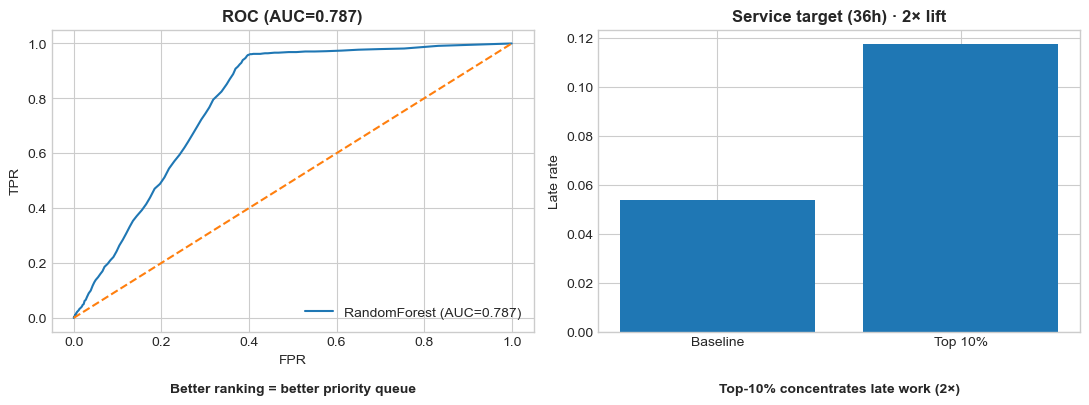

In [13]:
best_model = results_df.loc[0, "model"]
y_true_all = curves[best_model]["y_true"]
y_score_all = curves[best_model]["y_score"]
late_all = curves[best_model]["late_flag"]

fpr, tpr, _ = roc_curve(y_true_all, y_score_all)
auc = roc_auc_score(y_true_all, y_score_all)

baseline = float(late_all.mean())
top10 = float(top_k_precision(late_all, y_score_all, top_frac=QUEUE_PCT))
lift = (top10 / baseline) if baseline > 0 else float("nan")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# ROC
ax[0].plot(fpr, tpr, label=f"{best_model} (AUC={auc:.3f})")
ax[0].plot([0, 1], [0, 1], linestyle="--")
ax[0].set(xlabel="FPR", ylabel="TPR")
ax[0].set_title(f"ROC (AUC={auc:.3f})", fontweight="bold")
ax[0].legend(loc="lower right")
ax[0].text(0.5, -0.20, "Better ranking = better priority queue", transform=ax[0].transAxes, ha="center", fontweight="bold"
)

# SLA lift
ax[1].bar(["Baseline", f"Top {int(QUEUE_PCT*100)}%"], [baseline, top10])
ax[1].set(ylabel="Late rate")
ax[1].set_title(f"Service target ({SLA_HOURS:.0f}h) · {lift:.0f}× lift", fontweight="bold")
ax[1].text(0.5, -0.20, f"Top-10% concentrates late work ({lift:.0f}×)", transform=ax[1].transAxes, ha="center", fontweight="bold"
)

fig.tight_layout()
plt.show()

## Notes for stakeholders and reviewers

This model produces an intake risk score to prioritize work and protect **SLAs (time-based service targets)**.

- **Action:** rank incoming work and route the **top 10%** to a priority queue; success is **late-rate lift** in that queue vs baseline.
- **Rigor:** instrument-held-out CV (GroupKFold); fold-specific P90 labels; workload features use prior days only (shift(1)).
- **Service target view:** threshold is data-derived and rounded for readability.
